In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import statistics 
import numpy as np

df = pd.read_stata("/Volumes/USB322FD/GSS_stata/gss7224_r3.dta", convert_categoricals=False)


In [103]:
print(df.columns.tolist())
print(df["wrkstat"].value_counts())

df = df[df["wrkstat"] < 4]
print(df["wrkstat"].value_counts())

print(df["wrkstat"].value_counts())




['year', 'id', 'wrkstat', 'hrs1', 'hrs2', 'evwork', 'occ', 'prestige', 'wrkslf', 'wrkgovt', 'commute', 'industry', 'occ80', 'prestg80', 'indus80', 'indus07', 'occonet', 'found', 'occ10', 'occindv', 'occstatus', 'occtag', 'prestg10', 'prestg105plus', 'indus10', 'indstatus', 'indtag', 'marital', 'martype', 'agewed', 'divorce', 'widowed', 'spwrksta', 'sphrs1', 'sphrs2', 'spevwork', 'cowrksta', 'cowrkslf', 'coevwork', 'cohrs1', 'cohrs2', 'spocc', 'sppres', 'spwrkslf', 'spind', 'spocc80', 'sppres80', 'spind80', 'spocc10', 'spoccindv', 'spoccstatus', 'spocctag', 'sppres10', 'sppres105plus', 'spind10', 'spindstatus', 'spindtag', 'coocc10', 'coind10', 'paocc16', 'papres16', 'pawrkslf', 'paind16', 'paocc80', 'papres80', 'paind80', 'paocc10', 'paoccindv', 'paoccstatus', 'paocctag', 'papres10', 'papres105plus', 'paind10', 'paindstatus', 'paindtag', 'maocc80', 'mapres80', 'mawrkslf', 'maind80', 'maocc10', 'maoccindv', 'maoccstatus', 'maocctag', 'mapres10', 'mapres105plus', 'maind10', 'maindstatus'

In [104]:
print(df["satjob"].value_counts())
print(df["joblose"].value_counts())


satjob
1.0    20729
2.0    16685
3.0     4029
4.0     1493
Name: count, dtype: int64
joblose
4.0    16293
3.0     7008
2.0     1505
1.0     1166
5.0        5
Name: count, dtype: int64


In [105]:
print(df.info)

<bound method DataFrame.info of        year    id  wrkstat  hrs1  hrs2  evwork    occ  prestige  wrkslf  \
0      1972     1      1.0   NaN   NaN     NaN  205.0      50.0     2.0   
2      1972     3      2.0   NaN   NaN     NaN  270.0      44.0     2.0   
3      1972     4      1.0   NaN   NaN     NaN    1.0      57.0     2.0   
5      1972     6      1.0   NaN   NaN     NaN  281.0      49.0     2.0   
6      1972     7      1.0   NaN   NaN     NaN  522.0      41.0     2.0   
...     ...   ...      ...   ...   ...     ...    ...       ...     ...   
75690  2024  3301      3.0   NaN  40.0     NaN    NaN       NaN     1.0   
75692  2024  3303      1.0  40.0   NaN     NaN    NaN       NaN     2.0   
75694  2024  3305      2.0  15.0   NaN     NaN    NaN       NaN     2.0   
75695  2024  3306      2.0  18.0   NaN     NaN    NaN       NaN     2.0   
75697  2024  3308      1.0  37.0   NaN     NaN    NaN       NaN     2.0   

       wrkgovt  ...  famgen_exp_22  rplace_7522  hompop_7222  hompo

In [106]:

df = df[df["year"] <= 2015]
df = df[df["year"] >= 2003]
print(df.info)

<bound method DataFrame.info of        year    id  wrkstat  hrs1  hrs2  evwork  occ  prestige  wrkslf  \
43700  2004     3      1.0  40.0   NaN     NaN  NaN       NaN     2.0   
43701  2004     4      1.0  48.0   NaN     NaN  NaN       NaN     2.0   
43702  2004     5      1.0  36.0   NaN     NaN  NaN       NaN     2.0   
43704  2004     7      1.0  35.0   NaN     NaN  NaN       NaN     2.0   
43705  2004     8      2.0   NaN   NaN     NaN  NaN       NaN     2.0   
...     ...   ...      ...   ...   ...     ...  ...       ...     ...   
59591  2014  2536      1.0  48.0   NaN     NaN  NaN       NaN     2.0   
59595  2014  2540      1.0  46.0   NaN     NaN  NaN       NaN     2.0   
59596  2014  2541      1.0  40.0   NaN     NaN  NaN       NaN     2.0   
59597  2014  2542      1.0  40.0   NaN     NaN  NaN       NaN     2.0   
59598  2014  2543      2.0  48.0   NaN     NaN  NaN       NaN     2.0   

       wrkgovt  ...  famgen_exp_22  rplace_7522  hompop_7222  hompop_exp_22  \
43700      2

In [107]:
print(df["satjob"].value_counts())
print(df["satjob"].count())

satjob
1.0    4104
2.0    3105
3.0     692
4.0     275
Name: count, dtype: int64
8176


In [108]:
df = df[df["satjob"] >0]
df.info

<bound method DataFrame.info of        year    id  wrkstat  hrs1  hrs2  evwork  occ  prestige  wrkslf  \
43701  2004     4      1.0  48.0   NaN     NaN  NaN       NaN     2.0   
43704  2004     7      1.0  35.0   NaN     NaN  NaN       NaN     2.0   
43706  2004     9      2.0  25.0   NaN     NaN  NaN       NaN     2.0   
43707  2004    10      1.0  40.0   NaN     NaN  NaN       NaN     2.0   
43711  2004    14      2.0  12.0   NaN     NaN  NaN       NaN     2.0   
...     ...   ...      ...   ...   ...     ...  ...       ...     ...   
59591  2014  2536      1.0  48.0   NaN     NaN  NaN       NaN     2.0   
59595  2014  2540      1.0  46.0   NaN     NaN  NaN       NaN     2.0   
59596  2014  2541      1.0  40.0   NaN     NaN  NaN       NaN     2.0   
59597  2014  2542      1.0  40.0   NaN     NaN  NaN       NaN     2.0   
59598  2014  2543      2.0  48.0   NaN     NaN  NaN       NaN     2.0   

       wrkgovt  ...  famgen_exp_22  rplace_7522  hompop_7222  hompop_exp_22  \
43701      1

In [109]:
print(df['satjob'].value_counts(dropna=False))
print("dtype:", df['satjob'].dtype)
print("NaN count:", df['satjob'].isna().sum())

satjob
1.0    4104
2.0    3105
3.0     692
4.0     275
Name: count, dtype: int64
dtype: float64
NaN count: 0


In [110]:
# If satjob is numeric
mask_numeric = df['satjob'].isin([0, 8, 9])
print("Numeric reserved codes still present:", mask_numeric.sum())

# If satjob is string/object
suspicious = ['IAP', 'DK', 'NA', 'iap', 'dk', 'na', '.i', '.d', '.n',
              "Don't know", "No answer", "Not applicable"]
mask_string = df['satjob'].astype(str).isin(suspicious)
print("String reserved codes still present:", mask_string.sum())

Numeric reserved codes still present: 0
String reserved codes still present: 0


In [111]:
df['satjob'] = df['satjob'].replace([0, 8, 9], pd.NA)
# or for string format:
df.loc[df['satjob'].astype(str).isin(suspicious), 'satjob'] = pd.NA

In [112]:
controls = ['age', 'sex', 'race', 'educ', 'realrinc', 'coninc']  # adjust
summary = pd.DataFrame({
    'n_missing': df[controls].isna().sum(),
    'pct_missing': (df[controls].isna().mean() * 100).round(2)
})
print(summary)

          n_missing  pct_missing
age              21         0.26
sex               0         0.00
race              0         0.00
educ              9         0.11
realrinc       1343        16.43
coninc          705         8.62


In [113]:
analytic_vars = ['satjob', 'age', 'sex', 'race', 'educ', 'realrinc']
df_complete = df.dropna(subset=analytic_vars)
print(f"Starting N: {len(df)}")
print(f"Complete cases: {len(df_complete)}")
print(f"Lost to missingness: {len(df) - len(df_complete)} "
      f"({(len(df) - len(df_complete)) / len(df) * 100:.2f}%)")

Starting N: 8176
Complete cases: 6818
Lost to missingness: 1358 (16.61%)


In [114]:
def assign_period(year):
    if year in [2004, 2006]:
        return 'Pre-Recession (2004-2006)'
    elif year in [2008, 2010]:
        return 'Recession (2008-2010)'
    elif year in [2012, 2014]:
        return 'Post-Recession (2012-2014)'
    return None
df1=df.copy()

df1['period'] = df1['year'].apply(assign_period)
period_order = ['Pre-Recession (2004-2006)',
                'Recession (2008-2010)',
                'Post-Recession (2012-2014)']

# Readable label for satjob
satjob_labels = {1: 'Very Dissatisfied', 2: 'A Little Dissatisfied',
                 3: 'Moderately Satisfied', 4: 'Very Satisfied'}


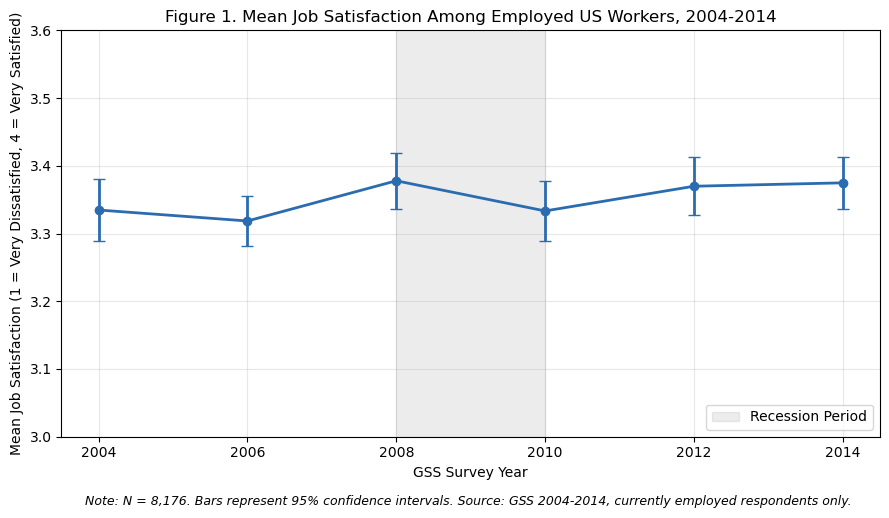

In [115]:
df1['satjob'] = 5 - df1['satjob']

df1['happy'] = 4 - df1['happy']

yearly = df1.groupby('year')['satjob'].agg(['mean', 'sem', 'count']).reset_index()
yearly['ci95'] = 1.96 * yearly['sem']

fig, ax = plt.subplots(figsize=(9, 5))
ax.axvspan(2008, 2010, alpha=0.15, color='gray', label='Recession Period')
ax.errorbar(yearly['year'], yearly['mean'], yerr=yearly['ci95'],
            marker='o', capsize=4, linewidth=2, color='#2b6cb0')

ax.set_xlabel('GSS Survey Year')
ax.set_ylabel('Mean Job Satisfaction (1 = Very Dissatisfied, 4 = Very Satisfied)')
ax.set_title('Figure 1. Mean Job Satisfaction Among Employed US Workers, 2004-2014')
ax.set_ylim(3.0, 3.6)  # zoom in; satjob means typically sit near 3.3
ax.set_xticks(yearly['year'])
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

n_total = yearly['count'].sum()
fig.text(0.1, -0.02,
         f'Note: N = {n_total:,}. Bars represent 95% confidence intervals. '
         f'Source: GSS 2004-2014, currently employed respondents only.',
         fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('figure1_mean_satjob_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

In [116]:
print(df1.groupby('satjob').size())
print("Mean satjob:", df1['satjob'].mean())

satjob
1.0     275
2.0     692
3.0    3105
4.0    4104
dtype: int64
Mean satjob: 3.3500489236790605


                            Very Dissatisfied  A Little Dissatisfied  \
period                                                                 
Pre-Recession (2004-2006)                4.14                   8.57   
Recession (2008-2010)                    3.01                   8.49   
Post-Recession (2012-2014)               2.81                   8.33   

                            Moderately Satisfied  Very Satisfied  
period                                                            
Pre-Recession (2004-2006)                  37.97           49.33  
Recession (2008-2010)                      38.36           50.14  
Post-Recession (2012-2014)                 37.64           51.22  
Each row should sum to 100: [100.0, 100.0, 100.0]


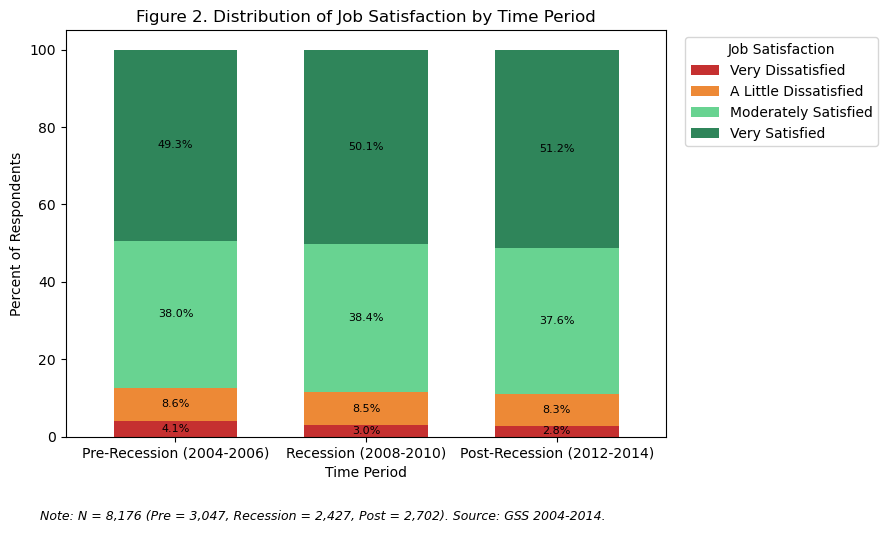

In [117]:
# Build the distribution using crosstab
dist = pd.crosstab(df1['period'], df1['satjob'], normalize='index') * 100
dist = dist.reindex(period_order)
dist.columns = [satjob_labels[c] for c in dist.columns]
dist = dist[['Very Dissatisfied', 'A Little Dissatisfied',
             'Moderately Satisfied', 'Very Satisfied']]

# Quick sanity check before plotting
print(dist.round(2))
print("Each row should sum to 100:", dist.sum(axis=1).round(2).tolist())

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c53030', '#ed8936', '#68d391', '#2f855a']
dist.plot(kind='bar', stacked=True, ax=ax, color=colors, width=0.65)

ax.set_xlabel('Time Period')
ax.set_ylabel('Percent of Respondents')
ax.set_title('Figure 2. Distribution of Job Satisfaction by Time Period')
ax.set_xticklabels(dist.index, rotation=0)
ax.legend(title='Job Satisfaction', bbox_to_anchor=(1.02, 1), loc='upper left')

# Annotate percentages on each segment
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

n_by_period = df1.groupby('period').size().reindex(period_order)
note = (f'Note: N = {n_by_period.sum():,} '
        f'(Pre = {n_by_period.iloc[0]:,}, Recession = {n_by_period.iloc[1]:,}, '
        f'Post = {n_by_period.iloc[2]:,}). Source: GSS 2004-2014.')
fig.text(0.05, -0.05, note, fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('figure2_satjob_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

/var/folders/8n/bhvj8n897qq6vv6zz0ss1pjm0000gr/T/ipykernel_98019/1621695596.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_period)


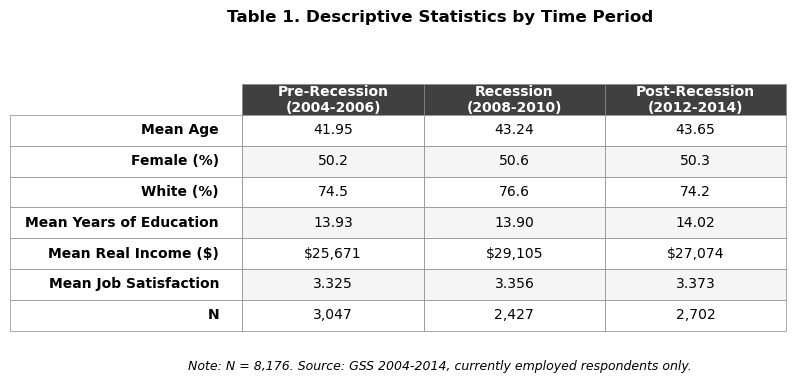

In [118]:
import matplotlib.table as tab
def summarize_period(group):
    return pd.Series({
        'Mean Age':                f'{group["age"].mean():.2f}',
        'Female (%)':              f'{(group["sex"] == 2).mean() * 100:.1f}',
        'White (%)':               f'{(group["race"] == 1).mean() * 100:.1f}',
        'Mean Years of Education': f'{group["educ"].mean():.2f}',
        'Mean Real Income ($)':    f'${group["realrinc"].mean():,.0f}',
        'Mean Job Satisfaction':   f'{group["satjob"].mean():.3f}',
        'N':                       f'{len(group):,}',
    })

table1 = (df1.groupby('period', group_keys=False)
              .apply(summarize_period)
              .reindex(period_order)
              .T)

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')

table1.columns = ['Pre-Recession\n(2004-2006)',
                  'Recession\n(2008-2010)',
                  'Post-Recession\n(2012-2014)']
tbl = ax.table(
    cellText=table1.values,
    rowLabels=table1.index,
    colLabels=table1.columns,
    cellLoc='center',
    rowLoc='right',
    loc='center',
    bbox=[0.20, 0.05, 0.78, 0.80],   # [left, bottom, width, height] in axes fraction
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

# Style header row (col labels)
for j in range(len(table1.columns)):
    cell = tbl[0, j]
    cell.set_facecolor('#404040')
    cell.set_text_props(color='white', weight='bold')

# Style row labels (variable names)
for i in range(1, len(table1.index) + 1):
    cell = tbl[i, -1]
    cell.set_text_props(weight='bold')

# Alternating row shading for readability
for i in range(1, len(table1.index) + 1):
    if i % 2 == 0:
        for j in range(len(table1.columns)):
            tbl[i, j].set_facecolor('#f5f5f5')

for key, cell in tbl.get_celld().items():
    cell.set_linewidth(0.5)
    cell.set_edgecolor('#888888')

plt.suptitle('Table 1. Descriptive Statistics by Time Period',
             fontsize=12, fontweight='bold', y=0.95)
fig.text(0.5, 0.05,
         f'Note: N = {len(df1):,}. Source: GSS 2004-2014, currently employed respondents only.',
         ha='center', fontsize=9, style='italic')

plt.savefig('table1_descriptives.png', dpi=300, bbox_inches='tight')
plt.show()


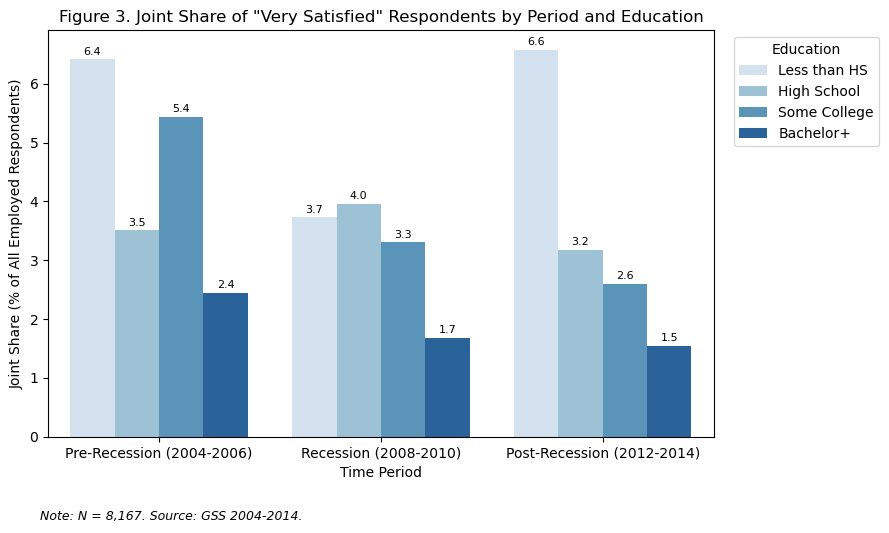

In [156]:
# Create education groups
def educ_group(years):
    if pd.isna(years): return None
    if years < 12: return 'Less than HS'
    elif years == 12: return 'High School'
    elif years < 16: return 'Some College'
    else: return 'Bachelor+'

df1['educ_group'] = df['educ'].apply(educ_group)
educ_order = ['Less than HS', 'High School', 'Some College', 'Bachelor+']

very_sat = (df1.assign(very_sat=(df['satjob'] == 4).astype(int))
              .groupby(['period', 'educ_group'])['very_sat']
              .mean().mul(100).reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
sb.barplot(data=very_sat, x='period', y='very_sat', hue='educ_group',
            order=period_order, hue_order=educ_order,
            palette='Blues', ax=ax)

ax.set_xlabel('Time Period')
ax.set_ylabel('Joint Share (% of All Employed Respondents)')
ax.set_title('Figure 3. Joint Share of "Very Satisfied" Respondents by Period and Education')
ax.legend(title='Education', bbox_to_anchor=(1.02, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)

fig.text(0.05, -0.05,
         f'Note: N = {len(df1.dropna(subset=["educ_group"])):,}. Source: GSS 2004-2014.',
         fontsize=9, style='italic')
plt.tight_layout()
plt.savefig('figure3_very_sat_by_period_educ.png', dpi=300, bbox_inches='tight')
plt.show()

In [120]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [121]:
df1['start_year'] = df1['year'] - df1['yearsjob']
df1['start_cohort'] = np.select(
    [
        df1['start_year'] < 2008,
        df1['start_year'].between(2008, 2010),
        df1['start_year'] > 2010,
    ],
    ['pre_recession', 'during_recession', 'post_recession'],
    default=None,
)
print(df1.start_cohort)



43701                None
43704                None
43706                None
43707                None
43711                None
               ...       
59591      post_recession
59595       pre_recession
59596      post_recession
59597    during_recession
59598       pre_recession
Name: start_cohort, Length: 8176, dtype: object


In [122]:
dat=df1
dat.head
results=smf.ols('satjob ~ C(period, Treatment("Pre-Recession (2004-2006)"))', data=dat).fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.848
Date:                Wed, 27 May 2026   Prob (F-statistic):             0.0580
Time:                        19:21:18   Log-Likelihood:                -9500.6
No. Observations:                8176   AIC:                         1.901e+04
Df Residuals:                    8173   BIC:                         1.903e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [123]:
results_educ=smf.ols('satjob ~ period + educ_group', data=dat).fit()
print(results_educ.summary())

dat.period

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     19.32
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.62e-19
Time:                        19:21:18   Log-Likelihood:                -9433.0
No. Observations:                8167   AIC:                         1.888e+04
Df Residuals:                    8161   BIC:                         1.892e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

43701     Pre-Recession (2004-2006)
43704     Pre-Recession (2004-2006)
43706     Pre-Recession (2004-2006)
43707     Pre-Recession (2004-2006)
43711     Pre-Recession (2004-2006)
                    ...            
59591    Post-Recession (2012-2014)
59595    Post-Recession (2012-2014)
59596    Post-Recession (2012-2014)
59597    Post-Recession (2012-2014)
59598    Post-Recession (2012-2014)
Name: period, Length: 8176, dtype: object

In [124]:
results_educ=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS"))', data=dat).fit()
print(results_educ.summary())


                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     19.32
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.62e-19
Time:                        19:21:18   Log-Likelihood:                -9433.0
No. Observations:                8167   AIC:                         1.888e+04
Df Residuals:                    8161   BIC:                         1.892e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [125]:
results_cont=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + realinc', data=dat).fit()
print(results_cont.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     31.83
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.34e-49
Time:                        19:21:18   Log-Likelihood:                -8506.9
No. Observations:                7455   AIC:                         1.703e+04
Df Residuals:                    7446   BIC:                         1.709e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [126]:
results_educ=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)"))', data=dat).fit()
print(results_educ.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.848
Date:                Wed, 27 May 2026   Prob (F-statistic):             0.0580
Time:                        19:21:18   Log-Likelihood:                -9500.6
No. Observations:                8176   AIC:                         1.901e+04
Df Residuals:                    8173   BIC:                         1.903e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [127]:
dat["adjrealinc"]= dat["realinc"]/10000
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + adjrealinc', data=dat).fit()
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     31.83
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.34e-49
Time:                        19:21:18   Log-Likelihood:                -8506.9
No. Observations:                7455   AIC:                         1.703e+04
Df Residuals:                    7446   BIC:                         1.709e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [128]:
from statsmodels.miscmodels.ordinal_model import OrderedModel


dat['satjob_ord'] = pd.Categorical(
    dat['satjob'],
    categories=[1.0, 2.0, 3.0, 4.0],
    ordered=True
)

import patsy

# Build the right-hand side of your Model 3 — note no intercept (OrderedModel adds cutpoints instead)
y, X = patsy.dmatrices(
    'satjob_ord ~ C(period, Treatment("Pre-Recession (2004-2006)")) '
    '+ C(educ_group, Treatment("Less than HS")) + age + sex + adjrealinc',
    data=dat,
    return_type='dataframe'
)
X = X.drop(columns='Intercept')
mod = OrderedModel(
    dat.loc[X.index, 'satjob_ord'],
    X,
    distr='logit'
)
res = mod.fit(method='bfgs', disp=False)
print(res.summary())

# res.params has the predictor coefficients, then the K-1 threshold parameters
cutpoint_params = res.params[-3:]  # last 3 entries for 4-category outcome
tau1 = cutpoint_params.iloc[0]
tau2 = tau1 + np.exp(cutpoint_params.iloc[1])
tau3 = tau2 + np.exp(cutpoint_params.iloc[2])
print(f"Cutpoints: {tau1:.3f}, {tau2:.3f}, {tau3:.3f}")

                             OrderedModel Results                             
Dep. Variable:             satjob_ord   Log-Likelihood:                -7594.5
Model:                   OrderedModel   AIC:                         1.521e+04
Method:            Maximum Likelihood   BIC:                         1.529e+04
Date:                Wed, 27 May 2026                                         
Time:                        19:21:19                                         
No. Observations:                7455                                         
Df Residuals:                    7444                                         
Df Model:                           8                                         
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------

In [129]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose + adjrealinc', data=dat).fit()
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     34.06
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.63e-59
Time:                        19:21:19   Log-Likelihood:                -5691.6
No. Observations:                5044   AIC:                         1.140e+04
Df Residuals:                    5034   BIC:                         1.147e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [130]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose + yearsjob + adjrealinc', data=dat).fit()
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     17.36
Date:                Wed, 27 May 2026   Prob (F-statistic):           6.84e-31
Time:                        19:21:19   Log-Likelihood:                -2861.2
No. Observations:                2499   AIC:                             5744.
Df Residuals:                    2488   BIC:                             5808.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [131]:
from statsmodels.miscmodels.ordinal_model import OrderedModel


dat['satjob_ord'] = pd.Categorical(
    dat['satjob'],
    categories=[1.0, 2.0, 3.0, 4.0],
    ordered=True
)

import patsy

# Build the right-hand side of your Model 3 — note no intercept (OrderedModel adds cutpoints instead)
y, X = patsy.dmatrices(
    'satjob_ord ~ C(period, Treatment("Pre-Recession (2004-2006)")) '
    '+ C(educ_group, Treatment("Less than HS"))+ age + sex + joblose + adjrealinc',
    data=dat,
    return_type='dataframe'
)
X = X.drop(columns='Intercept')
mod = OrderedModel(
    dat.loc[X.index, 'satjob_ord'],
    X,
    distr='logit'
)
res = mod.fit(method='bfgs', disp=False)
print(res.summary())

# res.params has the predictor coefficients, then the K-1 threshold parameters
cutpoint_params = res.params[-3:]  # last 3 entries for 4-category outcome
tau1 = cutpoint_params.iloc[0]
tau2 = tau1 + np.exp(cutpoint_params.iloc[1])
tau3 = tau2 + np.exp(cutpoint_params.iloc[2])
print(f"Cutpoints: {tau1:.3f}, {tau2:.3f}, {tau3:.3f}")

                             OrderedModel Results                             
Dep. Variable:             satjob_ord   Log-Likelihood:                -5093.9
Model:                   OrderedModel   AIC:                         1.021e+04
Method:            Maximum Likelihood   BIC:                         1.029e+04
Date:                Wed, 27 May 2026                                         
Time:                        19:21:20                                         
No. Observations:                5044                                         
Df Residuals:                    5032                                         
Df Model:                           9                                         
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------------

In [132]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose + goodlife + adjrealinc', data=dat).fit()
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.066
Method:                 Least Squares   F-statistic:                     17.82
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.02e-31
Time:                        19:21:20   Log-Likelihood:                -2627.5
No. Observations:                2375   AIC:                             5277.
Df Residuals:                    2364   BIC:                             5340.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [133]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose + adjrealinc', data=dat).fit(cov_type="hc3")
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     29.29
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.11e-50
Time:                        19:21:20   Log-Likelihood:                -5691.6
No. Observations:                5044   AIC:                         1.140e+04
Df Residuals:                    5034   BIC:                         1.147e+04
Df Model:                           9                                         
Covariance Type:                  hc3                                         
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [134]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose +earnrs + jobfind+ happy + partfull + hrs1 + adjrealinc', data=dat).fit()
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     37.94
Date:                Wed, 27 May 2026   Prob (F-statistic):           2.83e-98
Time:                        19:21:20   Log-Likelihood:                -4897.1
No. Observations:                4453   AIC:                             9824.
Df Residuals:                    4438   BIC:                             9920.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [135]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose +earnrs + jobfind + happy + partfull + hrs1 + incom16 + adjrealinc', data=dat).fit()
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     35.83
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.30e-98
Time:                        19:21:20   Log-Likelihood:                -4851.7
No. Observations:                4410   AIC:                             9735.
Df Residuals:                    4394   BIC:                             9838.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [136]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose +earnrs + jobfind + happy + partfull + hrs1 + incom16 + adjrealinc', data=dat).fit(cov_type="hc3")
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     33.45
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.57e-92
Time:                        19:21:20   Log-Likelihood:                -4851.7
No. Observations:                4410   AIC:                             9735.
Df Residuals:                    4394   BIC:                             9838.
Df Model:                          15                                         
Covariance Type:                  hc3                                         
                                                                                      coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

In [137]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose +earnrs + jobfind + happy + partfull + hrs1 + incom16 + wksup +wksub + adjrealinc', data=dat).fit()
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     32.19
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.39e-98
Time:                        19:21:20   Log-Likelihood:                -4566.1
No. Observations:                4164   AIC:                             9168.
Df Residuals:                    4146   BIC:                             9282.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [138]:
results_inc=smf.ols(formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)"))+ C(start_cohort, Treatment("pre_recession")) + C(educ_group, Treatment("Less than HS")) + age + sex + joblose +earnrs + jobfind + happy + partfull + hrs1 + incom16 + wksup +adjrealinc', data=dat).fit()
print(results_inc.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     17.87
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.59e-53
Time:                        19:21:20   Log-Likelihood:                -2598.6
No. Observations:                2348   AIC:                             5235.
Df Residuals:                    2329   BIC:                             5345.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [139]:
dat['year'].value_counts()

year
2006    1846
2014    1542
2008    1257
2004    1201
2010    1170
2012    1160
Name: count, dtype: int64

In [140]:
dat['start_cohort'].value_counts()

start_cohort
pre_recession       3023
during_recession     555
post_recession       527
Name: count, dtype: int64

In [141]:
df1.groupby('year')['start_cohort'].value_counts()

year  start_cohort    
2006  pre_recession       1712
2010  pre_recession        775
      during_recession     378
2014  pre_recession        536
      post_recession       527
      during_recession     177
Name: count, dtype: int64

In [142]:
dat_post=dat[dat['year'].isin([2010, 2014])].copy()

results_cohort = smf.ols(
    formula='satjob ~ C(start_cohort, Treatment("pre_recession")) + C(year) '
            '+ C(educ_group, Treatment("Less than HS")) '
            '+ age + sex + joblose + earnrs + jobfind + happy '
            '+ partfull + hrs1 + incom16 + wksup + adjrealinc + yearsjob',
    data=dat_post,
).fit()
print(results_cohort.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     13.25
Date:                Wed, 27 May 2026   Prob (F-statistic):           4.87e-37
Time:                        19:21:21   Log-Likelihood:                -1534.4
No. Observations:                1417   AIC:                             3107.
Df Residuals:                    1398   BIC:                             3207.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [143]:
dat_post=dat[dat['year'].isin([2010, 2014])].copy()

results_cohort = smf.ols(
    formula='satjob ~ C(start_cohort, Treatment("pre_recession")) + C(year) '
            '+ C(educ_group, Treatment("Less than HS")) '
            '+ age + sex + joblose + earnrs + jobfind + happy '
            '+ partfull + hrs1 + incom16 + wksup + adjrealinc + yearsjob',
    data=dat_post,
).fit(cov_type="HC3")
print(results_cohort.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     13.64
Date:                Wed, 27 May 2026   Prob (F-statistic):           3.01e-38
Time:                        19:21:21   Log-Likelihood:                -1534.4
No. Observations:                1417   AIC:                             3107.
Df Residuals:                    1398   BIC:                             3207.
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                                                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------

In [144]:
dat_post=dat[dat['year'].isin([2010, 2014])].copy()

results_cohort = smf.ols(
    formula='satjob ~ C(start_cohort, Treatment("pre_recession")) + C(year) '
            '+ C(educ_group, Treatment("Less than HS")) '
            '+ age + sex + joblose + earnrs + jobfind + happy '
            '+ partfull + hrs1 + incom16 + wksup + wksub + adjrealinc + yearsjob',
    data=dat_post,
).fit()
print(results_cohort.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.146
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     12.61
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.11e-36
Time:                        19:21:21   Log-Likelihood:                -1533.9
No. Observations:                1417   AIC:                             3108.
Df Residuals:                    1397   BIC:                             3213.
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [145]:
dat[['joblose','happy','satjob']].corr()

,joblose,happy,satjob
joblose,1.000000,0.166998,0.192463
happy,0.166998,1.000000,0.248798
satjob,0.192463,0.248798,1.000000


In [146]:
from statsmodels.iolib.summary2 import summary_col
import statsmodels.formula.api as smf
df['white'] = np.where(df['race'].isna(), np.nan, (df['race'] == 1).astype(int))
# Sample restrictions
dat_full = dat.copy()
dat_qwl = dat.copy()
dat_cohort = dat[dat['year'].isin([2010, 2014])].copy()

# Model 1: Baseline period model on full sample
m1 = smf.ols(
    'satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) '
    '+ C(educ_group, Treatment("Less than HS")) '
    '+ age + sex + race + adjrealinc',
    data=dat_full,
).fit(cov_type='HC3')

# Model 2: Period model with QWL controls on QWL subsample
m2 = smf.ols(
    'satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) '
    '+ C(educ_group, Treatment("Less than HS")) '
    '+ age + sex + race + adjrealinc '
    '+ joblose + jobfind + happy + earnrs + hrs1 '
    '+ incom16 + wksup + wksub+ partfull',
    data=dat_qwl,
).fit(cov_type='HC3')

m3 = smf.ols(
    'satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) '
    '+ C(educ_group, Treatment("Less than HS")) '
    '+ age + sex + race + adjrealinc '
    '+ joblose + jobfind +yearsjob+ happy + earnrs + hrs1 '
    '+ incom16 + wksup + wksub+ partfull',
    data=dat_qwl,
).fit(cov_type='HC3')

# Model 3: Cohort model on 2010+2014 with year FE
m4 = smf.ols(
    'satjob ~ C(start_cohort, Treatment("pre_recession")) + C(year) '
    '+ C(educ_group, Treatment("Less than HS")) '
    '+ age + sex + race + adjrealinc '
    '+ joblose + jobfind + happy + yearsjob + earnrs + hrs1 '
    '+ incom16 + wksup + wksub + partfull',
    data=dat_cohort,
).fit(cov_type='HC3')

# Build the combined table
table = summary_col(
    [m1, m2, m3],
    model_names=['Model 1\n(Full Sample)', 'Model 2\n(QWL Subsample)', 'Model 3\n(2010+2014)'],
    stars=True,
    float_format='%0.3f',
    info_dict={
        'N': lambda x: f"{int(x.nobs):,}",
        'R-squared': lambda x: f"{x.rsquared:.3f}",
        'Adj. R-squared': lambda x: f"{x.rsquared_adj:.3f}",
    },
    regressor_order=[
        'Intercept',
        'C(period, Treatment("Pre-Recession (2004-2006)"))[T.Recession (2008-2010)]',
        'C(period, Treatment("Pre-Recession (2004-2006)"))[T.Post-Recession (2012-2014)]',
        'C(start_cohort, Treatment("pre_recession"))[T.during_recession]',
        'C(start_cohort, Treatment("pre_recession"))[T.post_recession]',
        'joblose',
        'happy',
        'yearsjob',
    ],
)

print(table)

/var/folders/8n/bhvj8n897qq6vv6zz0ss1pjm0000gr/T/ipykernel_98019/571309420.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['white'] = np.where(df['race'].isna(), np.nan, (df['race'] == 1).astype(int))



                                                                                   Model 1        Model 2       Model 3  
                                                                                (Full Sample) (QWL Subsample) (2010+2014)
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                                       2.882***      1.875***        1.714***   
                                                                                (0.055)       (0.150)         (0.209)    
C(period, Treatment("Pre-Recession (2004-2006)"))[T.Recession (2008-2010)]      0.038*        0.088***        0.068*     
                                                                                (0.022)       (0.029)         (0.038)    
C(period, Treatment("Pre-Recession (2004-2006)"))[T.Post-Recession (2012-2014)] 0.041*        0.059**         0.031      
                       

In [147]:
dat_qwl.year.value_counts()

year
2006    1846
2014    1542
2008    1257
2004    1201
2010    1170
2012    1160
Name: count, dtype: int64

In [148]:
with open('table2.html', 'w') as f:
    f.write(table.as_html())

print(table)


                                                                                   Model 1        Model 2       Model 3  
                                                                                (Full Sample) (QWL Subsample) (2010+2014)
-------------------------------------------------------------------------------------------------------------------------
Intercept                                                                       2.882***      1.875***        1.714***   
                                                                                (0.055)       (0.150)         (0.209)    
C(period, Treatment("Pre-Recession (2004-2006)"))[T.Recession (2008-2010)]      0.038*        0.088***        0.068*     
                                                                                (0.022)       (0.029)         (0.038)    
C(period, Treatment("Pre-Recession (2004-2006)"))[T.Post-Recession (2012-2014)] 0.041*        0.059**         0.031      
                       

In [149]:
import pandas as pd

def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

# Map raw statsmodels names → display names
label_map = {
    'Intercept': 'Intercept',
    'C(period, Treatment("Pre-Recession (2004-2006)"))[T.Recession (2008-2010)]': 'Recession (2008-2010)',
    'C(period, Treatment("Pre-Recession (2004-2006)"))[T.Post-Recession (2012-2014)]': 'Post-Recession (2012-2014)',
    'C(start_cohort, Treatment("pre_recession"))[T.during_recession]': 'Started job during recession',
    'C(start_cohort, Treatment("pre_recession"))[T.post_recession]': 'Started job post-recession',
    'C(year)[T.2014]': 'Year = 2014',
    'joblose': 'Perceived job security',
    'jobfind': 'Could find another job',
    'happy': 'General happiness',
    'yearsjob': 'Years at current job',
    'hrs1': 'Hours worked last week',
    'earnrs': 'Other earners in household',
    'wksup': 'Has supervisor',
    'partfull': 'Part-time vs full-time',
    'incom16': 'Family income at age 16',
    'C(educ_group, Treatment("Less than HS"))[T.High School]': 'High School',
    'C(educ_group, Treatment("Less than HS"))[T.Some College]': 'Some College',
    'C(educ_group, Treatment("Less than HS"))[T.Bachelor+]': 'Bachelor+ degree',
    'age': 'Age',
    'sex': 'Female',
    'adjrealinc': 'Real income (per $10k)',
}

models = [m1, m2, m3]
model_names = ['Model 1 (Full)', 'Model 2 (QWL)', 'Model 3 (2010+2014)']

rows = []
for raw, display in label_map.items():
    coef_row = [display]
    se_row = ['']
    has_any = False
    for m in models:
        if raw in m.params.index:
            coef_row.append(f"{m.params[raw]:.3f}{stars(m.pvalues[raw])}")
            se_row.append(f"({m.bse[raw]:.3f})")
            has_any = True
        else:
            coef_row.append('')
            se_row.append('')
    if has_any:
        rows.append(coef_row)
        rows.append(se_row)

# Bottom statistics
rows.append(['N'] + [f"{int(m.nobs):,}" for m in models])
rows.append(['R-squared'] + [f"{m.rsquared:.3f}" for m in models])
rows.append(['Adj. R-squared'] + [f"{m.rsquared_adj:.3f}" for m in models])

table = pd.DataFrame(rows, columns=['Variable'] + model_names)
print(table.to_string(index=False))

# Export
table.to_html('table2.html', index=False, border=1)
table.to_csv('table2.csv', index=False)
table.to_latex('table2.tex', index=False)

                  Variable Model 1 (Full) Model 2 (QWL) Model 3 (2010+2014)
                 Intercept       2.882***      1.875***            1.714***
                                  (0.055)       (0.150)             (0.209)
     Recession (2008-2010)          0.038       0.088**               0.068
                                  (0.022)       (0.029)             (0.038)
Post-Recession (2012-2014)          0.041        0.059*               0.031
                                  (0.021)       (0.029)             (0.037)
    Perceived job security                     0.115***            0.117***
                                                (0.017)             (0.024)
    Could find another job                      -0.035*              -0.025
                                                (0.015)             (0.021)
         General happiness                     0.279***            0.277***
                                                (0.021)             (0.028)
      Years 

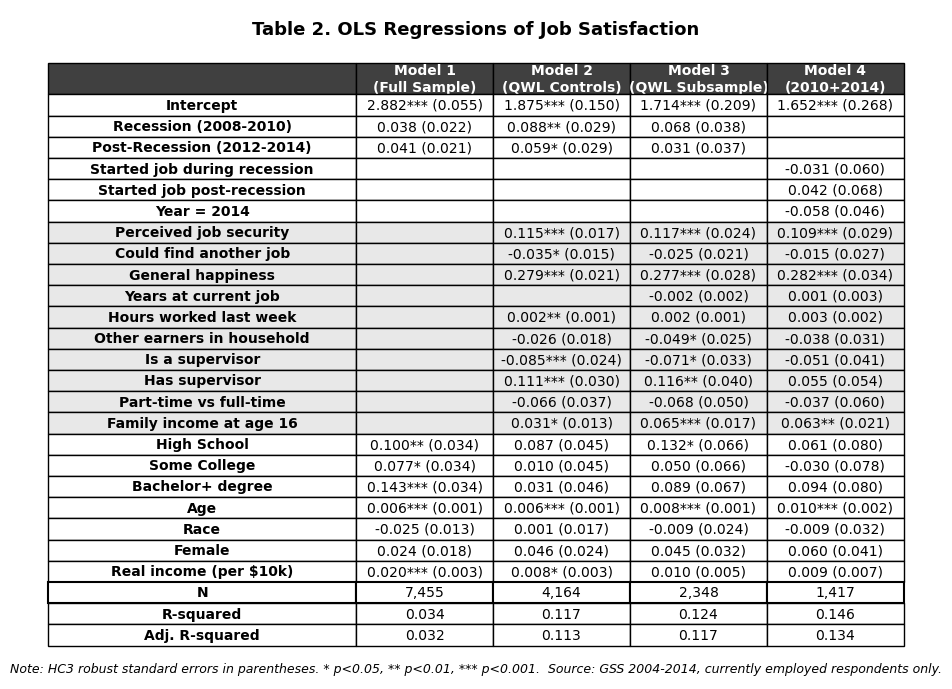

In [150]:
"""
Generate Table 2 as a PNG matching the Table 1 style.

Run this from a notebook cell after fitting m1, m2, m3. It extracts coefficients
from the statsmodels results objects directly, so it stays in sync with whatever
model specifications you're running.
"""
import matplotlib.pyplot as plt

def make_table2(m1, m2, m3, m4, outpath='table2_regression.png'):
    label_map = {
        'Intercept': 'Intercept',
        'C(period, Treatment("Pre-Recession (2004-2006)"))[T.Recession (2008-2010)]': 'Recession (2008-2010)',
        'C(period, Treatment("Pre-Recession (2004-2006)"))[T.Post-Recession (2012-2014)]': 'Post-Recession (2012-2014)',
        'C(start_cohort, Treatment("pre_recession"))[T.during_recession]': 'Started job during recession',
        'C(start_cohort, Treatment("pre_recession"))[T.post_recession]': 'Started job post-recession',
        'C(year)[T.2014]': 'Year = 2014',
        'joblose': 'Perceived job security',
        'jobfind': 'Could find another job',
        'happy': 'General happiness',
        'yearsjob': 'Years at current job',
        'hrs1': 'Hours worked last week',
        'earnrs': 'Other earners in household',
        'wksup': 'Is a supervisor',
        'wksub': 'Has supervisor', 
        'partfull': 'Part-time vs full-time',
        'incom16': 'Family income at age 16',
        'C(educ_group, Treatment("Less than HS"))[T.High School]': 'High School',
        'C(educ_group, Treatment("Less than HS"))[T.Some College]': 'Some College',
        'C(educ_group, Treatment("Less than HS"))[T.Bachelor+]': 'Bachelor+ degree',
        'age': 'Age',
        'race': 'Race',
        'sex': 'Female',
        'adjrealinc': 'Real income (per $10k)',
    }
    qwl_rows = {'Perceived job security', 'Could find another job', 'General happiness',
                'Years at current job', 'Hours worked last week', 'Other earners in household',
                'Has supervisor', 'Is a supervisor', 'Part-time vs full-time', 'Family income at age 16'}
    models = [m1, m2, m3, m4]

    def stars(p):
        return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''

    header = ['', 'Model 1\n(Full Sample)', 'Model 2\n(QWL Controls)',
          'Model 3\n(QWL Subsample)', 'Model 4\n(2010+2014)']
    rows = [header]
    for raw, display in label_map.items():
        row = [display]
        has_any = False
        for m in models:
            if raw in m.params.index:
                coef = m.params[raw]
                se = m.bse[raw]
                p = m.pvalues[raw]
                row.append(f"{coef:.3f}{stars(p)} ({se:.3f})")
                has_any = True
            else:
                row.append('')
        if has_any:
            rows.append(row)
    rows.append(['N'] + [f"{int(m.nobs):,}" for m in models])
    rows.append(['R-squared'] + [f"{m.rsquared:.3f}" for m in models])
    rows.append(['Adj. R-squared'] + [f"{m.rsquared_adj:.3f}" for m in models])

    n_rows, n_cols = len(rows), 5
    fig, ax = plt.subplots(figsize=(11.5, 0.30 * n_rows + 0.6))
    ax.axis('off'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    table = ax.table(
        cellText=rows, cellLoc='center', colWidths=[0.36, 0.16, 0.16, 0.16, 0.16],
        bbox=[0.02, 0.05, 0.96, 0.87],
    )
    table.auto_set_font_size(False); table.set_fontsize(10)

    for j in range(n_cols):
        c = table[(0, j)]; c.set_facecolor('#404040')
        c.set_text_props(color='white', weight='bold')
        c.set_height(c.get_height() * 1.5)

    for i in range(1, n_rows):
       table[(i, 0)].set_text_props(weight='bold')
       if rows[i][0] in qwl_rows:
           for j in range(n_cols):
               table[(i, j)].set_facecolor('#e8e8e8')
    
    n_row_idx = next(i for i, r in enumerate(rows) if r[0] == 'N')
    for j in range(n_cols):
       table[(n_row_idx, j)].set_edgecolor('black')
       table[(n_row_idx, j)].set_linewidth(1.5)
    
    ax.text(0.5, 0.97, 'Table 2. OLS Regressions of Job Satisfaction',
            ha='center', va='center', fontsize=13, weight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.015,
            'Note: HC3 robust standard errors in parentheses. * p<0.05, ** p<0.01, *** p<0.001.  '
            'Source: GSS 2004-2014, currently employed respondents only.',
            ha='center', va='center', fontsize=9, style='italic', transform=ax.transAxes)

    plt.savefig('table2_regression.png', dpi=200, bbox_inches='tight', facecolor='white', pad_inches=0.15)
    plt.show()
    
make_table2(m1, m2, m3, m4)


In [151]:

dat['joblose_c'] = dat['joblose'] - dat['joblose'].mean()
results_interact = smf.ols(
    formula='satjob ~ C(period, Treatment("Pre-Recession (2004-2006)")) * joblose_c '
            '+ C(educ_group, Treatment("Less than HS")) '
            '+ age + sex + earnrs + jobfind + happy + partfull '
            '+ hrs1 + incom16 + wksup + wksub + adjrealinc',
    data=dat
).fit(cov_type="hc3")
print(results_interact.summary())

                            OLS Regression Results                            
Dep. Variable:                 satjob   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     28.44
Date:                Wed, 27 May 2026   Prob (F-statistic):           7.61e-96
Time:                        19:21:24   Log-Likelihood:                -4565.9
No. Observations:                4164   AIC:                             9172.
Df Residuals:                    4144   BIC:                             9299.
Df Model:                          19                                         
Covariance Type:                  hc3                                         
                                                                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

/var/folders/8n/bhvj8n897qq6vv6zz0ss1pjm0000gr/T/ipykernel_98019/3661224891.py:49: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


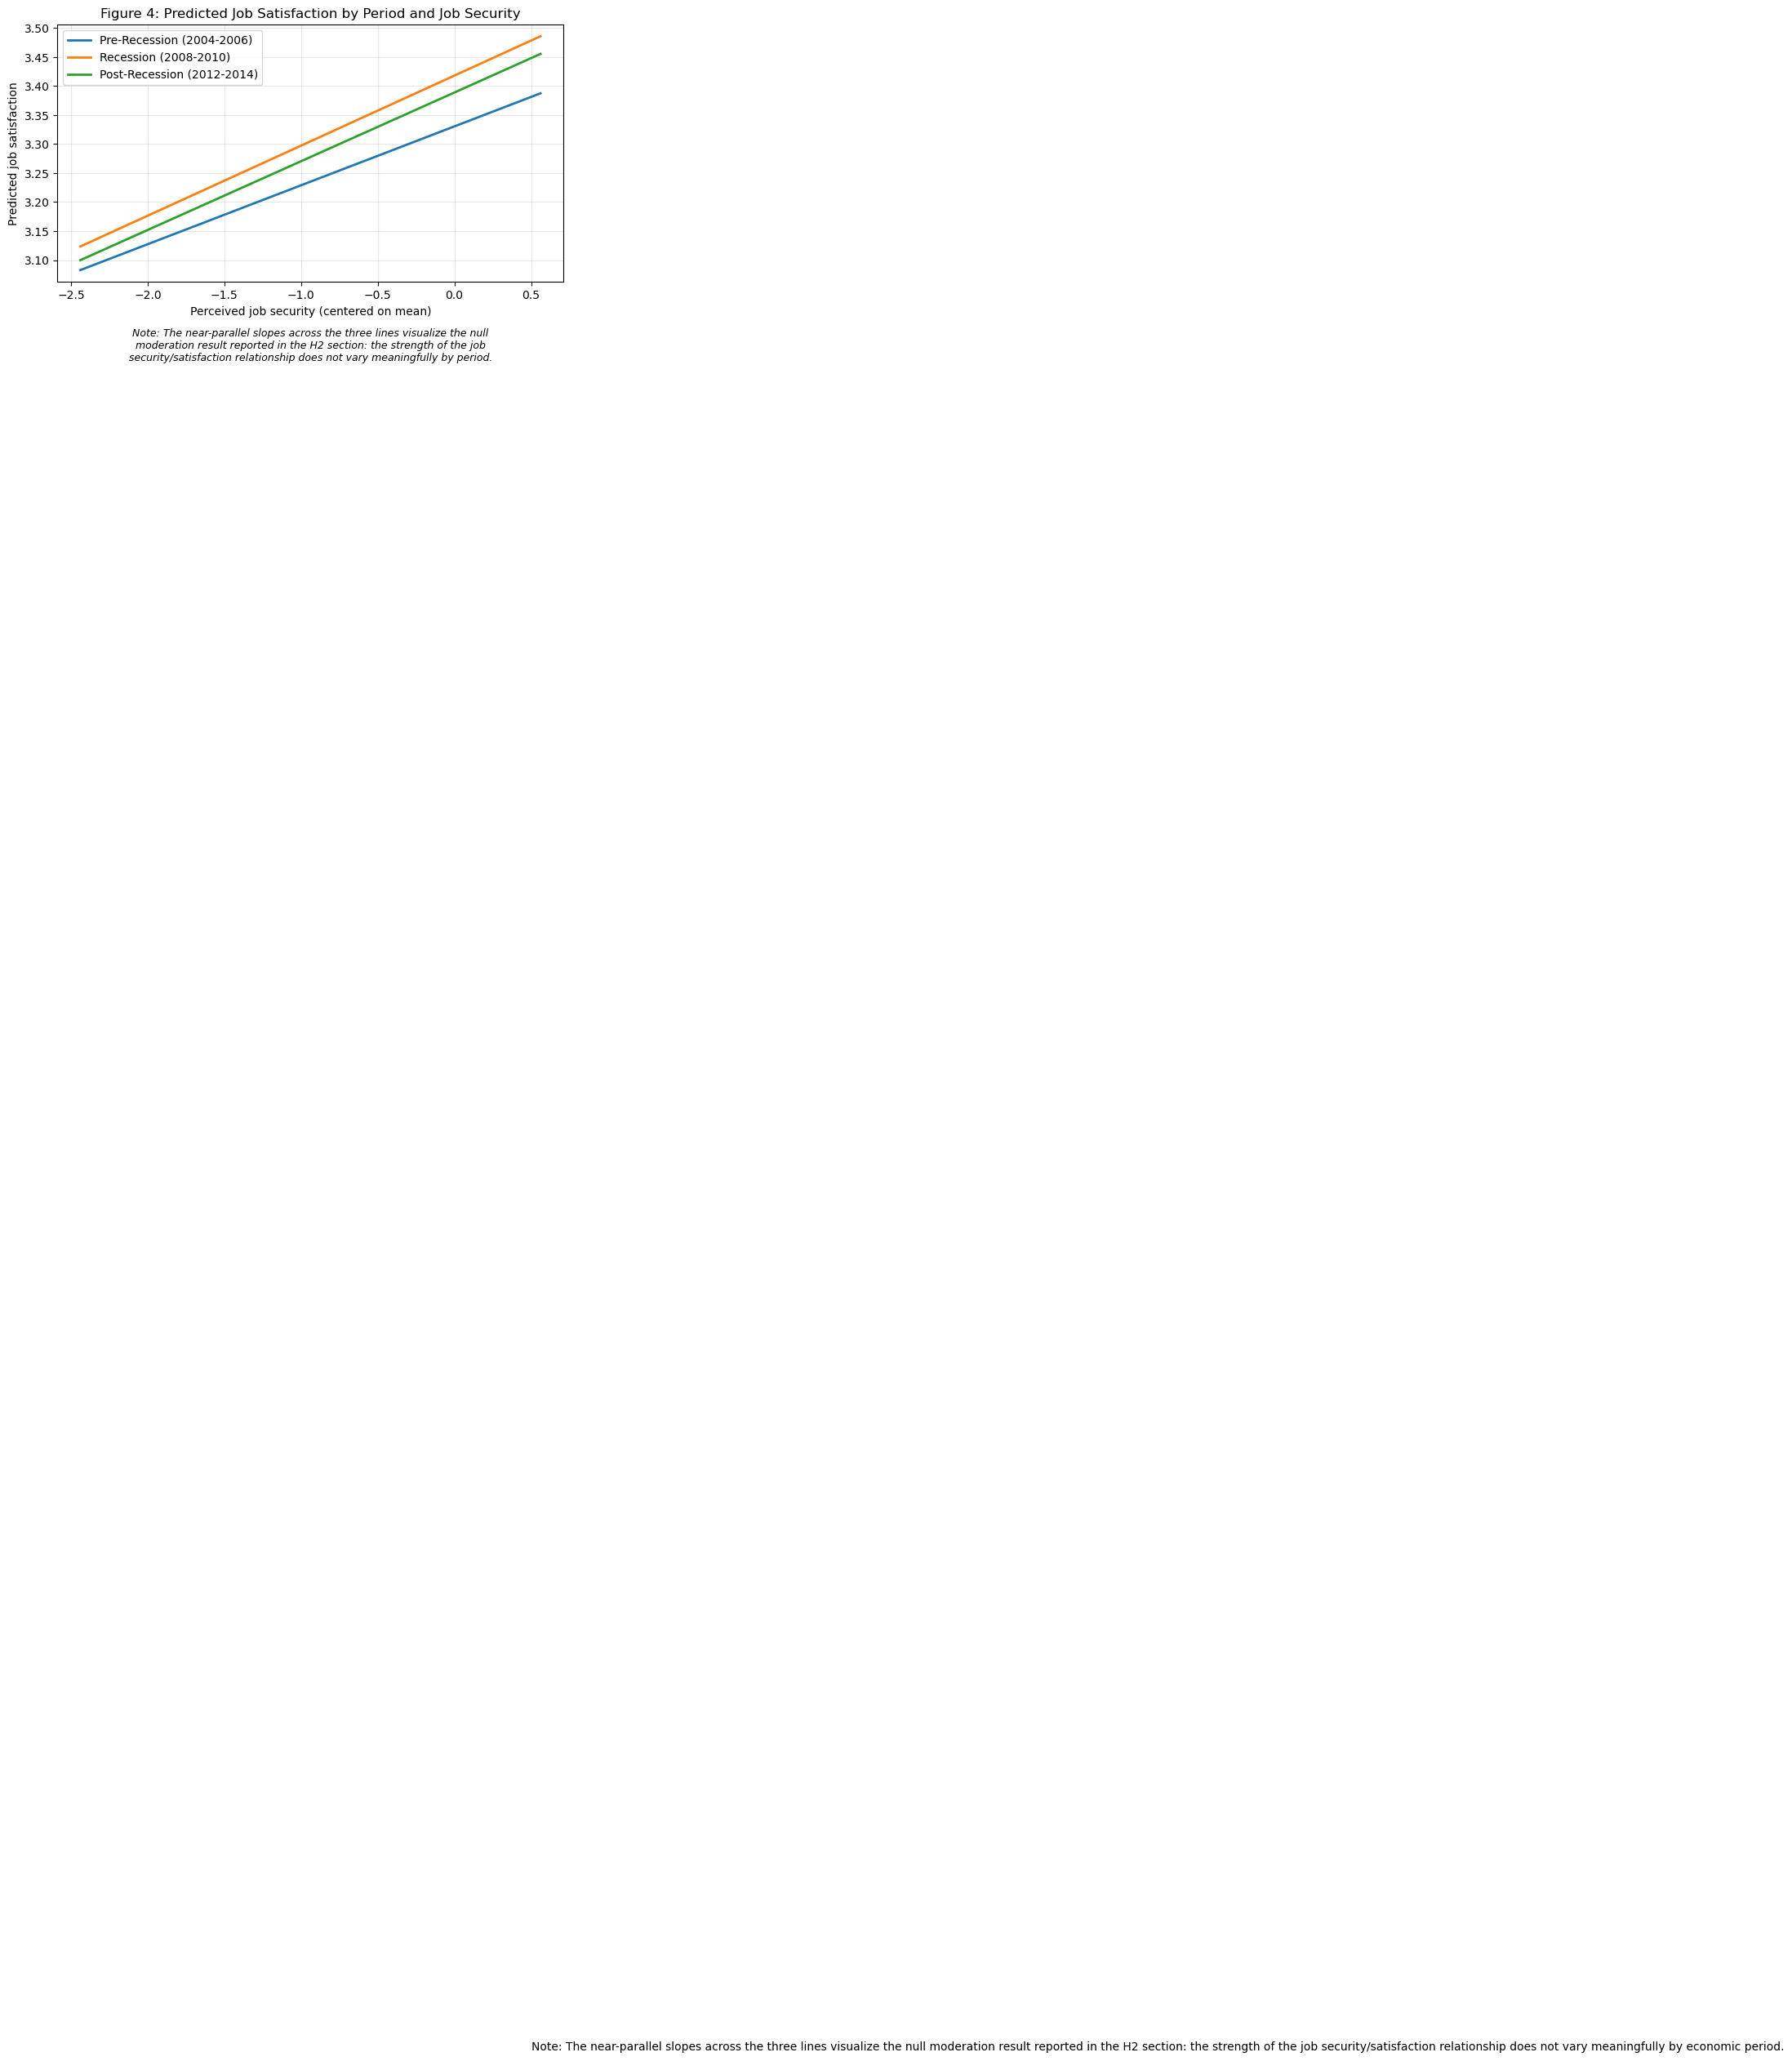

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# build a "reference respondent" at the means/modes of every covariate
analytic_vars = ['joblose_c', 'age', 'sex', 'earnrs', 'jobfind', 'happy',
                 'partfull', 'hrs1', 'incom16', 'wksup', 'wksub', 'adjrealinc']

# use the model's analytic sample, not the full df
sample = results_interact.model.data.frame

ref = {v: sample[v].mean() for v in analytic_vars}
ref['educ_group'] = 'High School'  # set to a real category from your data

# vary joblose_c across its observed range
joblose_range = np.linspace(sample['joblose_c'].min(),
                            sample['joblose_c'].max(), 50)

periods = ['Pre-Recession (2004-2006)',
           'Recession (2008-2010)',
           'Post-Recession (2012-2014)']

fig, ax = plt.subplots(figsize=(8, 5))
for p in periods:
    pred_data = pd.DataFrame({**ref, 'joblose_c': joblose_range, 'period': p})
    preds = results_interact.predict(pred_data)
    ax.plot(joblose_range, preds, label=p, linewidth=2)

# convert centered axis back to original joblose scale for readability
joblose_mean = sample['joblose_c'].mean() * 0  # already centered, so 0
ax.set_xlabel('Perceived job security (centered on mean)')
ax.set_ylabel('Predicted job satisfaction')
ax.text(0.5, 0.015, "Note: The near-parallel slopes across the three lines visualize the null moderation result reported in the H2 section: the strength of the job security/satisfaction relationship does not vary meaningfully by economic period.")
ax.set_title('Figure 4: Predicted Job Satisfaction by Period and Job Security')
ax.text(
    0.5, -0.18,
    "Note: The near-parallel slopes across the three lines visualize the null\n"
    "moderation result reported in the H2 section: the strength of the job\n"
    "security/satisfaction relationship does not vary meaningfully by period.",
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=9,
    style='italic'
)
plt.subplots_adjust(bottom=0.25)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('interaction_plot.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

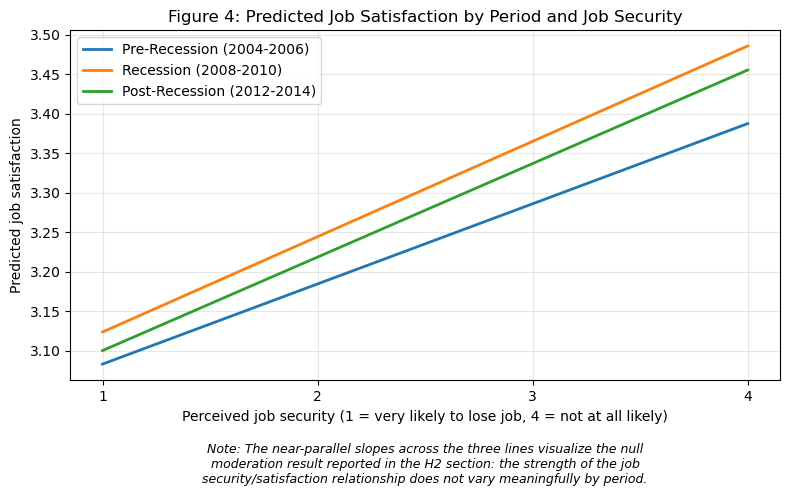

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# build a "reference respondent" at the means/modes of every covariate
analytic_vars = ['joblose_c', 'age', 'sex', 'earnrs', 'jobfind', 'happy', 'race',
                 'partfull', 'hrs1', 'incom16', 'wksup', 'wksub', 'adjrealinc']

sample = results_interact.model.data.frame

ref = {v: sample[v].mean() for v in analytic_vars}
ref['educ_group'] = 'High School'

# the original mean you centered on — replace with your actual value
# if joblose_c = joblose - joblose.mean(), then joblose_mean is that mean
joblose_mean = dat['joblose'].mean()   # or whatever variable holds the uncentered joblose

joblose_range = np.linspace(sample['joblose_c'].min(),
                            sample['joblose_c'].max(), 50)

# the original-scale values for axis labels
joblose_original = joblose_range + joblose_mean

periods = ['Pre-Recession (2004-2006)',
           'Recession (2008-2010)',
           'Post-Recession (2012-2014)']

fig, ax = plt.subplots(figsize=(8, 5))
for p in periods:
    pred_data = pd.DataFrame({**ref, 'joblose_c': joblose_range, 'period': p})
    preds = results_interact.predict(pred_data)
    # plot using the original-scale x-values
    ax.plot(joblose_original, preds, label=p, linewidth=2)

ax.set_xlabel('Perceived job security (1 = very likely to lose job, 4 = not at all likely)')
ax.set_ylabel('Predicted job satisfaction')
ax.set_title('Figure 4: Predicted Job Satisfaction by Period and Job Security')
ax.legend()
ax.grid(alpha=0.3)

# optional: force integer ticks at 1, 2, 3, 4
ax.set_xticks([1, 2, 3, 4])
ax.text(
    0.5, -0.18,
    "Note: The near-parallel slopes across the three lines visualize the null\n"
    "moderation result reported in the H2 section: the strength of the job\n"
    "security/satisfaction relationship does not vary meaningfully by period.",
    transform=ax.transAxes,
    ha='center',
    va='top',
    fontsize=9,
    style='italic'
)
plt.subplots_adjust(bottom=0.25)
plt.tight_layout()
plt.savefig('interaction_plot.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

In [154]:
dat_qwl.dropna(subset=['satjob','joblose','jobfind','happy','earnrs','hrs1',
                       'incom16','wksup','partfull','adjrealinc','age','sex','educ_group']
              )['year'].value_counts()

year
2006    991
2014    901
2008    687
2010    687
2012    649
2004    250
Name: count, dtype: int64